# Pydantic

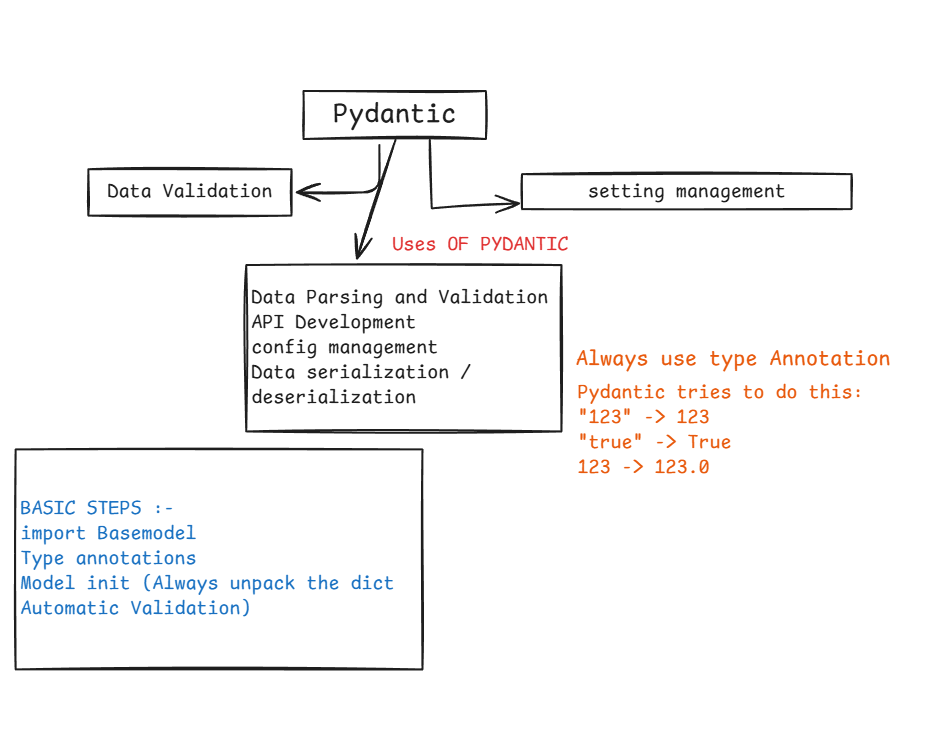

In [ ]:
print("start of pyadantic journey")

In [ ]:
from pydantic import BaseModel


In [ ]:

class User(BaseModel):
    id: int
    name: str
    is_active : bool 

input_data={'id':'101','name':"HeexonCode",'is_active':True}
user=User(**input_data)

for i in user:
    print(i)
print(user)

### Unpacking concepts

In [ ]:
#unpacking concepts

input_data={'id':101,'name':"HeexonCode",'is_active':True}
user=User(**input_data)
print(user.id)
print(user.name)
print(user.is_active)

a,b,c=[12,34,56]
print(a)
print(b)
print(c)

test=input_data
print(test['id'])
print(test['name'])
print(test['is_active'])


## Pydantic Default Conversions

In [ ]:
class Product(BaseModel):
    id: int
    name: str
    price: float
    in_stock: bool= True
    
product_one=Product(id=1,name="Laptop",price=999.99,in_stock=True)

product_two=Product(id=2,name="Smartphone",price=499.99)

# product_three=Product(name="Headphones") 3 VAlidationError: 2 validation errors for Product

print(product_one)
print(product_two)

## Mixing Pydantic and Typing in Python

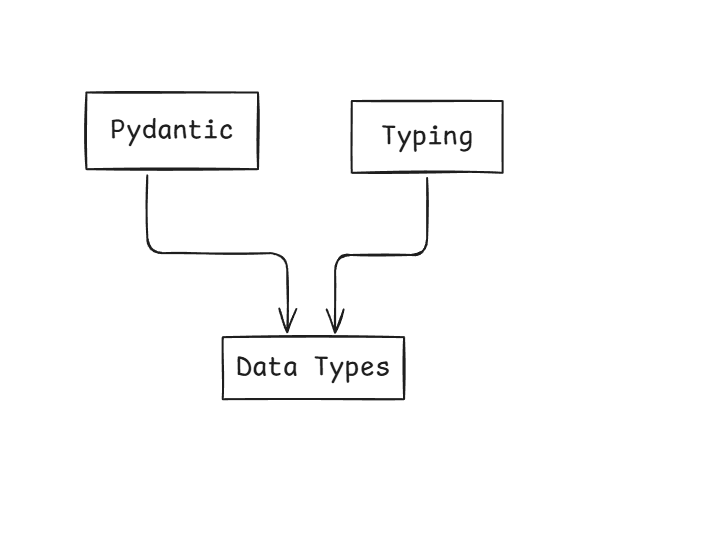

In [ ]:
from pydantic import BaseModel
from typing import List,Dict,Optional

class Cart(BaseModel):
    user_id:int 
    items : List[str] # mixing pydantic with typing module
    quantities:Dict[str,int] # mixing pydantic with typing module

class BlogPost(BaseModel):
    title:str
    content:str
    image_url: Optional[str] =None # Optional field with default value None
    


## Adding Validations with Field

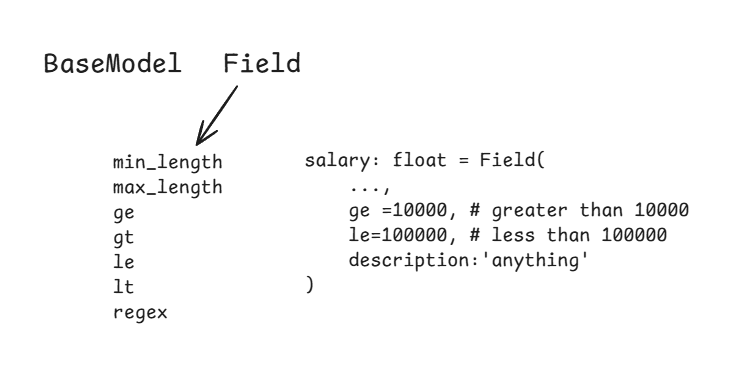

In [ ]:
cart_data={
    "user_id":123,
    "items":["Laptop","Smartphone","Headphones"],
    "quantities":{"Laptop":1,"Smartphone":2,"Headphones":3},
}

cart=Cart(**cart_data)
print(cart)

In [ ]:
from typing import Optional
from pydantic import BaseModel,Field
import re

class Employee(BaseModel):
    id:int
    name: str = Field(
        ..., # Ellipsis indicates that this field is required
        min_length=3, #
        max_length=50,
        description="The name of the employee, must be between 3 and 50 characters.",
        example="Ayush Maurya"
    )
    department: Optional[str] ='General'
    salary: float = Field(
        ...,
        ge=10000, # 'ge':- greater than or equal to 10000
    )

class User(BaseModel):
    email: str = Field(..., pattern = r'') 
    phone: str = Field(..., pattern= r'')
    age: int = Field(
        ...,
        ge=0,
        le=150,
        description="The age of the user, must be between 0 and 150.", 
    )
    discount: float = Field(
        ...,
        ge=0,
        le=100,
        description="discount percentage",
    )


## Field and model validations in Python

In [1]:
from pydantic import BaseModel, field_validator,model_validator

class User(BaseModel):
    username: str 


    @field_validator('username')
    def username_length(cls,v):
        if len(v)<4:
            raise ValueError("Username must be atleast 4 characters Long")
        return v
    

class signup_data(BaseModel):
    password: str
    confirm_password: str 


    @model_validator(mode='after')
    def passwords_match(cls,values):
        if values.password != values.confirm_password:
            raise ValueError("Passwords do not match")
        return values


C:\Users\Ayush Maurya\AppData\Local\Temp\ipykernel_3852\4063525947.py:19: PydanticDeprecatedSince212: Using `@model_validator` with mode='after' on a classmethod is deprecated. Instead, use an instance method. See the documentation at https://docs.pydantic.dev/2.12/concepts/validators/#model-after-validator. Deprecated in Pydantic V2.12 to be removed in V3.0.
  @model_validator(mode='after')


## Computed Property in Pydantic

In [8]:
from pydantic import BaseModel,computed_field,Field

class Product(BaseModel):
    price : float
    quantity: int

    @computed_field # it is computed when we access it not when we create an instance
    @property # it is accessed like an attribute not like a method
    def total_price(self) -> float:
        return self.price * self.quantity
    

class Booking(BaseModel):
    user_id: int 
    room_id: int
    nights: int = Field(...,ge=1)
    rate_per_night: float

    @computed_field
    @property
    def total_amount(self) -> float:
        return self.nights * self.rate_per_night
    

booking= Booking(
    user_id=123,
    room_id=456,
    nights=3,
    rate_per_night=100.0
)

print(booking)
print(booking.total_amount) 

print(booking.model_dump())

user_id=123 room_id=456 nights=3 rate_per_night=100.0 total_amount=300.0
300.0
{'user_id': 123, 'room_id': 456, 'nights': 3, 'rate_per_night': 100.0, 'total_amount': 300.0}


## Advance Validations in Pydantic

In [9]:
from pydantic import BaseModel,field_validator,model_validator
from datetime import datetime

class Person(BaseModel):
    first_name: str
    last_name: str


    @field_validator('first_name','last_name')
    def names_must_be_capitalized(cls,v):
        if not v.istitle():
            raise ValueError("Names must be capitalized")
        return v

class User(BaseModel):
    email : str

    @field_validator('email')
    def normalize_email(cls,v):
        return v.lower().strip()
    

class Product(BaseModel):
    price : str # $4.44


    @field_validator('price',mode='before')
    def parse_price(cls,v):
        if isinstance(v,str):
            return float(v.replace('$',''))
        return v
    
class date_range(BaseModel):
    start_date: datetime
    end_time : datetime
    


    @model_validator(mode='after')
    def validate_date_range(cls,values):
        if values.start_date>= values.end_time:
            raise ValueError("end_date must be after start_date")
        return values
    
    

C:\Users\Ayush Maurya\AppData\Local\Temp\ipykernel_5764\2317391527.py:39: PydanticDeprecatedSince212: Using `@model_validator` with mode='after' on a classmethod is deprecated. Instead, use an instance method. See the documentation at https://docs.pydantic.dev/2.12/concepts/validators/#model-after-validator. Deprecated in Pydantic V2.12 to be removed in V3.0.
  @model_validator(mode='after')


## Nested Models in Pydantic

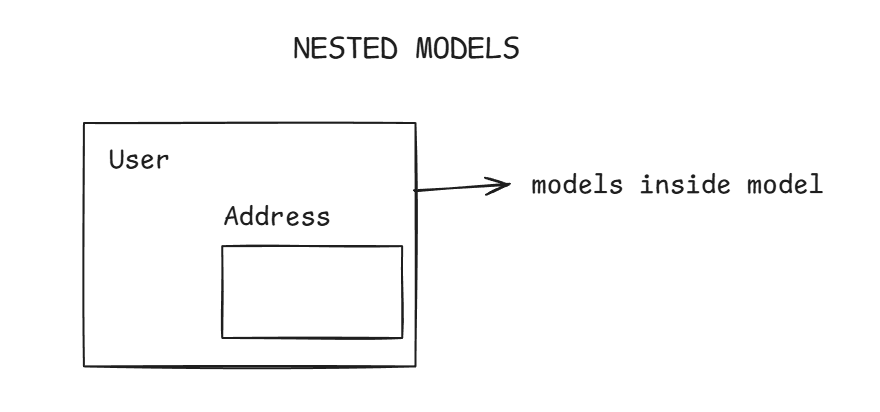

In [ ]:
from typing import List,Dict
from unicodedata import name
from pydantic import BaseModel

class Address(BaseModel):
    street : str
    city: str
    postal_code: str


class User(BaseModel):
    id: int
    name: str
    address : Address # nesting models

address=Address(
    street="123 Main St",
    city="Anytown",
    postal_code="12345"
)

user=User(
    id=1,
    name="ayush",
    address=address,
)

# we can also create user by this way by unpacking the data
user_data={
    'id':2,
    "name": "ayush",
    "address": {
        "street":"123 Main St",
        "city":"Greater noida",
        "postal_code":"89945"
    }
}

user1=User(**user_data)
print(user1)



id=2 name='ayush' address=Address(street='123 Main St', city='Greater noida', postal_code='89945')


## Self Referencing models (Recursive Models)

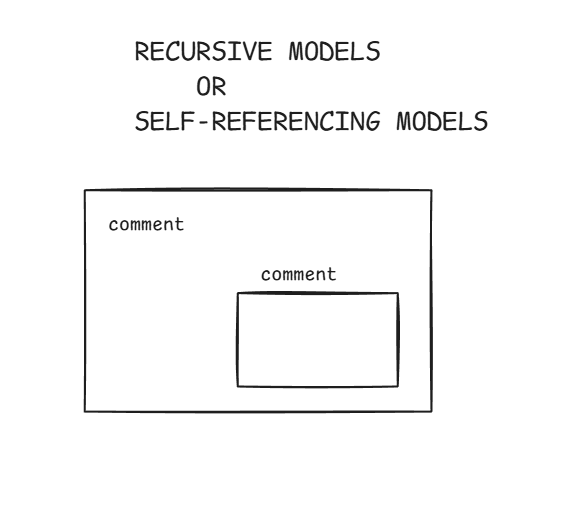

In [ ]:
from typing import List,Dict,Optional
from pydantic import  BaseModel

class Comment(BaseModel):
    id: int
    content: str
    replies: Optional[List['Comment']] =None # recursive models must be optional and have default value None


Comment.model_rebuild() # to rebuild the model after defining the recursive model

comment=Comment(
    id=1,
    content="first comment",
    replies=[
        Comment(id=2,content='Reply 1'),
        Comment(id=3,content='Reply 2',replies=[
            Comment(id=4,content='Nested Reply')
        ]),
    ]

)

## Advance nested model

In [4]:
from pydantic import BaseModel
from typing import Optional,Union

class Address(BaseModel):
    street : str
    city: str
    postal_code: str

class Company(BaseModel):
    name: str
    address: Optional[Address]= None

class Employee(BaseModel):
    name: str
    company: Optional[Company] = None
    

class Text_content(BaseModel):
    type: str = "text" # type field to distinguish between different content types
    content: str

class Image_content(BaseModel):
    type: str ="Image"
    url : str
    alt_text: str

class Article(BaseModel):
    title: str
    sections: List[Union[Text_content,Image_content]] # Union to allow multiple content types in sections


class Country(BaseModel):
    name: str
    code: str

class State(BaseModel):
    name: str
    country : Country

class City(BaseModel):
    name: str
    state: State

class Address(BaseModel):
    street: str
    city: City
    postal_code: str

class Organization(BaseModel):
    name: str
    headquarters: Address
    branches: List[Address]=[]